# Avtomobil Narxini Bashorat Qilish — Amaliyot


**Ustunlar:**
- `car_age` — avtomobilning yoshi (yil)
- `mileage` — bosib o'tilgan masofa (km)
- `engine_size` — dvigatel hajmi (litr)
- `owners` — avvalgi egalari soni
- `fuel_type` — yoqilg'i turi: petrol / diesel / hybrid / electric
- `transmission` — uzatma turi: manual / automatic
- `accident_history` — avariyaga uchraganmi (yes/no)
- `city_tier` — sotiladigan shahar darajasi: tier1 / tier2 / tier3
- `price` — maqsadli o'zgaruvchi (bashorat qilmoqchi bo'lgan narximiz)

Ma'lumotlarga ataylab bir nechta takrorlangan qatorlar va bo'sh (missing) qiymatlar qo'shilgan. Bo'limlarni tartib bilan bajaring — keyingi qadamlar avvalgi tozalash ishlariga bog'liq.

In [4]:
%pip install numpy pandas seaborn matplotlib scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## 1. Ma'lumotlarni yuklash
`car_price.csv` faylini `df` nomli DataFrame'ga

In [6]:
# TODO: CSV faylini df ga yuklang
df= pd.read_csv("car_price.csv")
df

,car_age,mileage,engine_size,owners,fuel_type,transmission,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,manual,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,automatic,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,manual,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,manual,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,automatic,no,tier1,22904.57
...,...,...,...,...,...,...,...,...,...
1359,10,129571,1.7,2,petrol,manual,no,tier2,11101.30
1360,0,500,2.0,2,petrol,automatic,no,tier1,29774.28
1361,9,116905,2.6,0,diesel,manual,no,tier2,11321.43
1362,10,130171,2.1,0,petrol,automatic,yes,tier3,6631.13


## 2. Dastlabki ko'rib chiqish
Quyidagilarni tekshiring:
- `df.info()`
- `df.describe(include="all")`
- `df.columns`

In [7]:
# TODO
df.info()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_age           1364 non-null   int64  
 1   mileage           1364 non-null   int64  
 2   engine_size       1346 non-null   float64
 3   owners            1364 non-null   int64  
 4   fuel_type         1364 non-null   object 
 5   transmission      1364 non-null   object 
 6   accident_history  1364 non-null   object 
 7   city_tier         1364 non-null   object 
 8   price             1364 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 96.0+ KB


,car_age,mileage,engine_size,owners,fuel_type,transmission,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,manual,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,automatic,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,manual,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,manual,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,automatic,no,tier1,22904.57
...,...,...,...,...,...,...,...,...,...
1359,10,129571,1.7,2,petrol,manual,no,tier2,11101.30
1360,0,500,2.0,2,petrol,automatic,no,tier1,29774.28
1361,9,116905,2.6,0,diesel,manual,no,tier2,11321.43
1362,10,130171,2.1,0,petrol,automatic,yes,tier3,6631.13


In [8]:
df.describe(include="all")
df

,car_age,mileage,engine_size,owners,fuel_type,transmission,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,manual,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,automatic,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,manual,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,manual,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,automatic,no,tier1,22904.57
...,...,...,...,...,...,...,...,...,...
1359,10,129571,1.7,2,petrol,manual,no,tier2,11101.30
1360,0,500,2.0,2,petrol,automatic,no,tier1,29774.28
1361,9,116905,2.6,0,diesel,manual,no,tier2,11321.43
1362,10,130171,2.1,0,petrol,automatic,yes,tier3,6631.13


In [9]:
df.columns

Index(['car_age', 'mileage', 'engine_size', 'owners', 'fuel_type',
       'transmission', 'accident_history', 'city_tier', 'price'],
      dtype='object')

## 3. Ma'lumotlarni Tahlil Qilish (EDA)
Darsda qilgan grafiklarimizga o'xshash grafiklarni shu ma'lumot uchun qayta yarating:
1. Sonli ustunlar uchun gistogrammalar (KDE bilan): `car_age`, `mileage`, `engine_size`, `owners`, `price`
2. `fuel_type`, `transmission`, `accident_history`, `city_tier` uchun countplot'lar
3. `fuel_type` uchun sonlarni ko'rsatuvchi (bar label) countplot
4. `car_age` va `price` o'rtasidagi `relplot`, `accident_history` bo'yicha rangланган
5. Har bir sonli ustun uchun boxplot (chetga chiqib ketgan qiymatlarni topish uchun)
6. Sonli ustunlar o'rtasidagi korrelyatsiya heatmap'i

Qaysi o'zgaruvchi `price` bilan eng kuchli vizual bog'liqlikka ega ko'rinadi? `accident_history` narx tendensiyasini sezilarli darajada o'zgartiradimi?

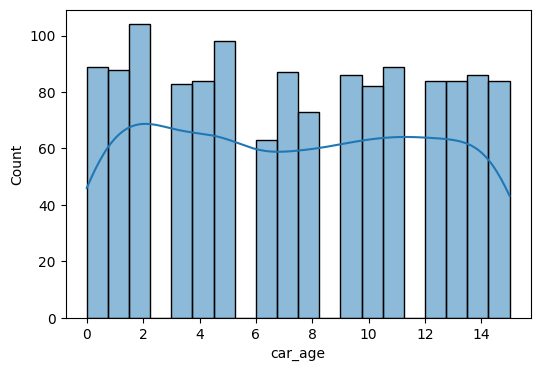

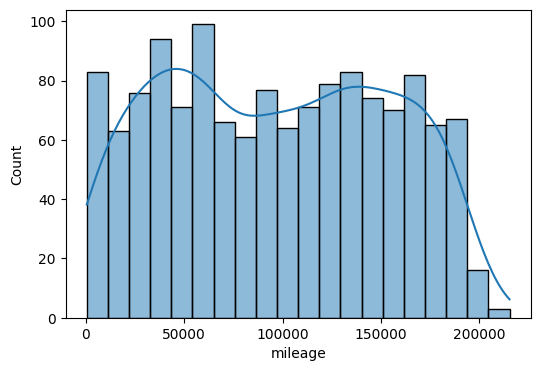

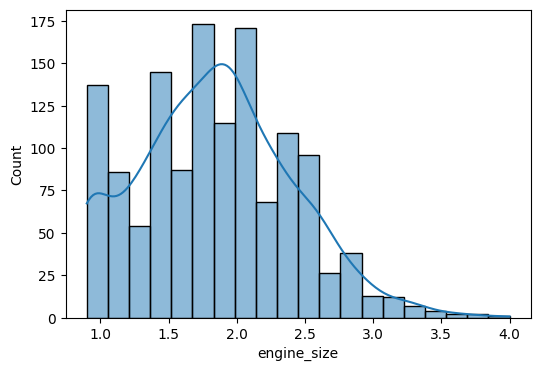

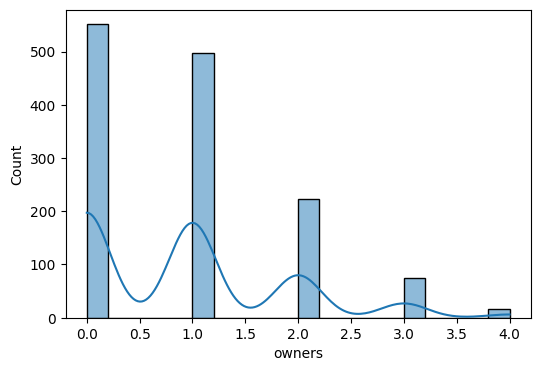

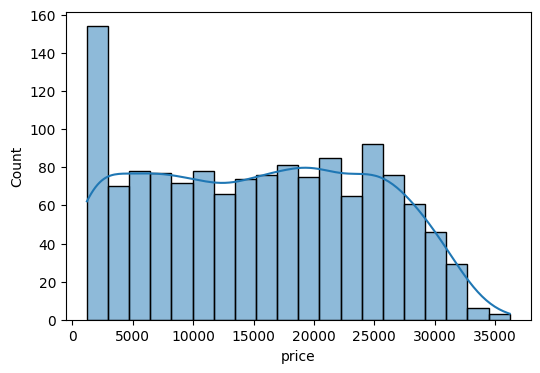

In [10]:
# TODO: gistogrammalar
numeric_columns=['car_age', 'mileage','engine_size', 'owners','price']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='fuel_type', ylabel='count'>

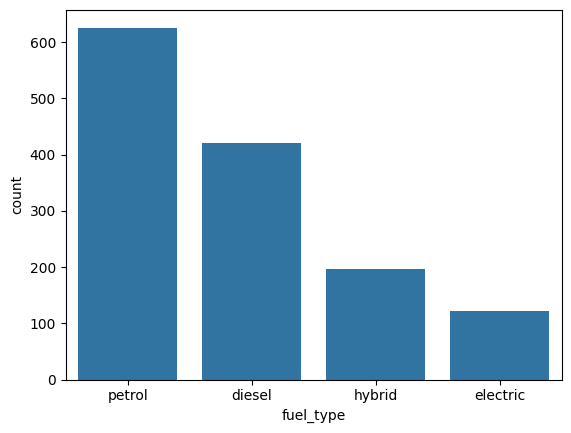

In [11]:
# TODO: countplot'lar
sns.countplot(x=df['fuel_type'])

<Axes: xlabel='transmission', ylabel='count'>

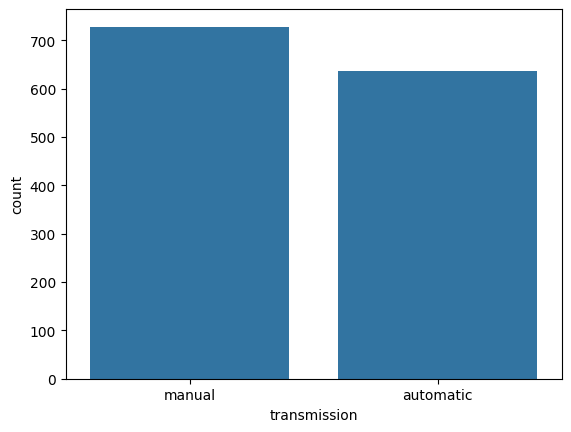

In [12]:
sns.countplot(x=df['transmission'])

<Axes: xlabel='accident_history', ylabel='count'>

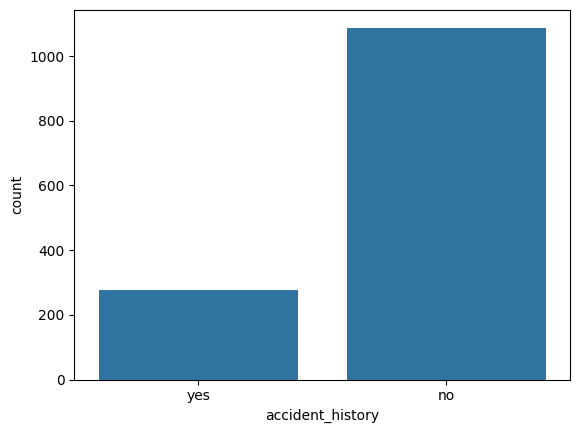

In [13]:
sns.countplot(x=df['accident_history'])

<Axes: xlabel='city_tier', ylabel='count'>

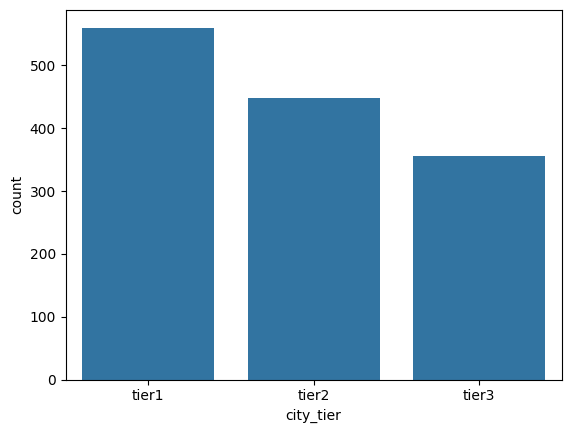

In [14]:
sns.countplot(x=df['city_tier'])

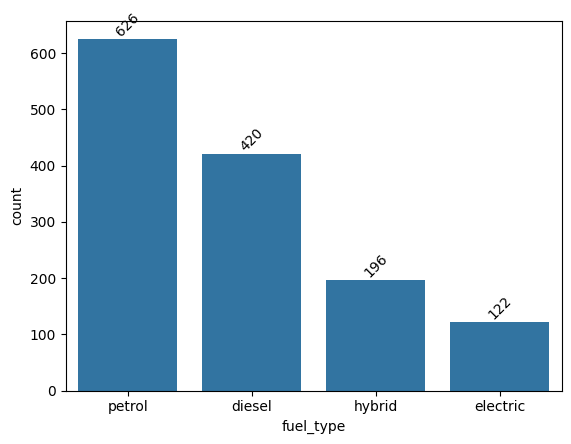

In [15]:
# TODO: fuel_type uchun bar label bilan countplot
ax=sns.countplot(x=df['fuel_type'])
ax.bar_label(ax.containers[0],fmt='%.0f', rotation=45)
plt.show()

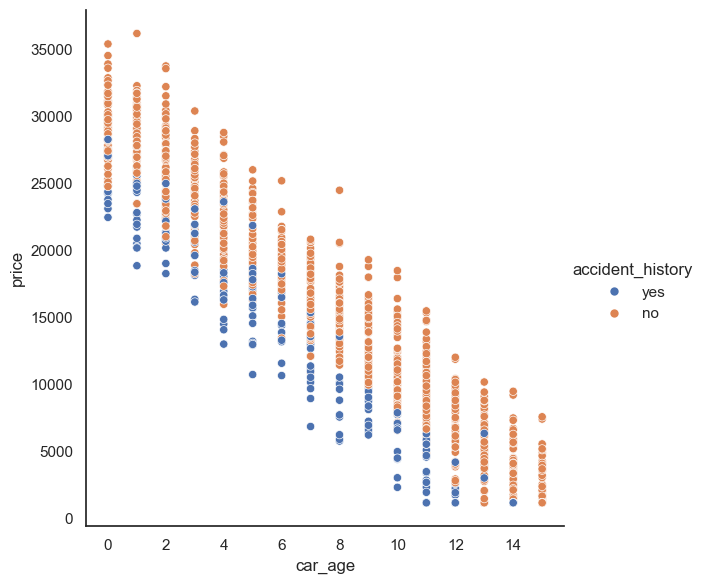

In [16]:
# TODO: car_age vs price, accident_history bo'yicha relplot
sns.set_theme(style="white")
sns.relplot( data=df,
            x="car_age", y="price",
            hue="accident_history",
            height=6)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_age           1364 non-null   int64  
 1   mileage           1364 non-null   int64  
 2   engine_size       1346 non-null   float64
 3   owners            1364 non-null   int64  
 4   fuel_type         1364 non-null   object 
 5   transmission      1364 non-null   object 
 6   accident_history  1364 non-null   object 
 7   city_tier         1364 non-null   object 
 8   price             1364 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 96.0+ KB


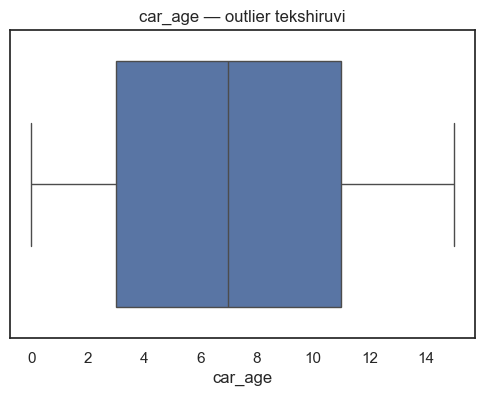

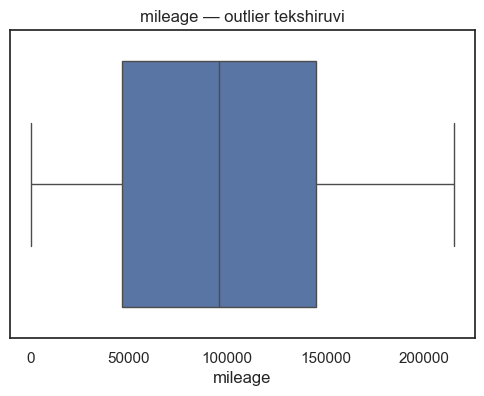

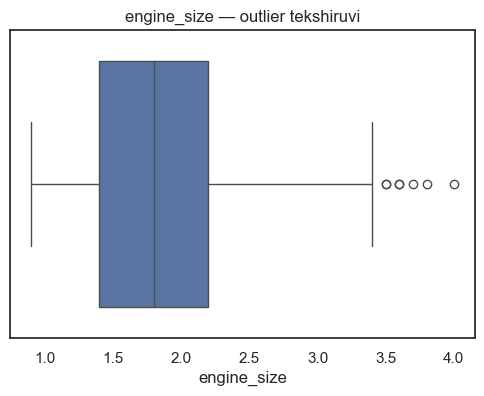

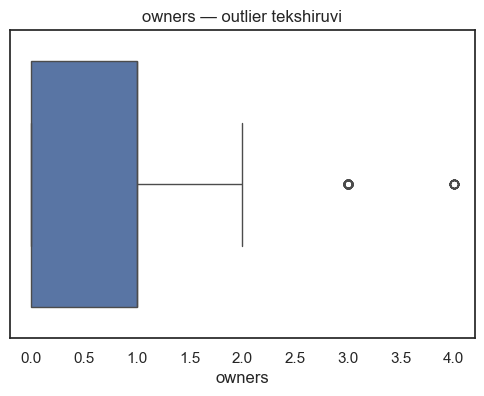

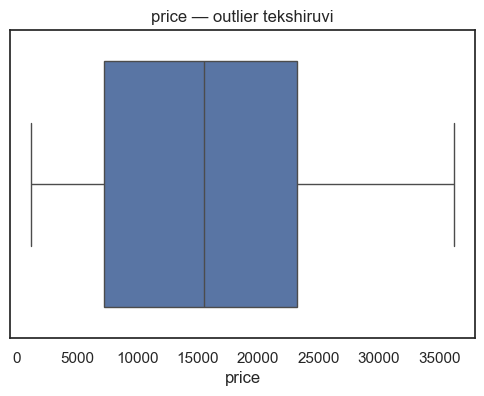

In [18]:
# TODO: boxplot'lar
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — outlier tekshiruvi")
    plt.show()

<Axes: >

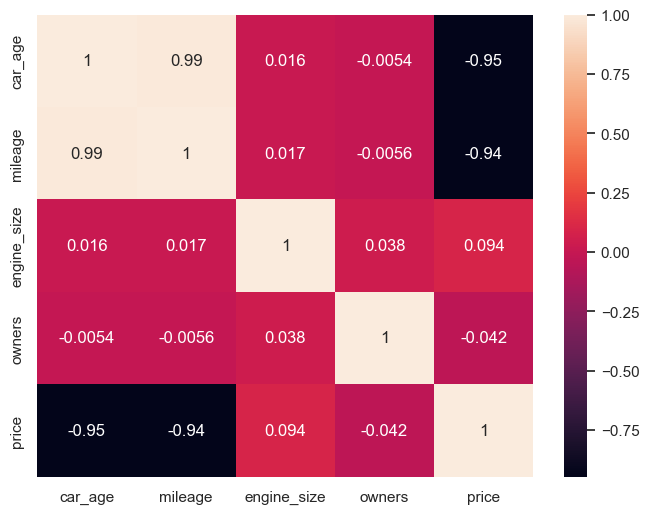

In [19]:
# TODO: korrelyatsiya heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_age           1364 non-null   int64  
 1   mileage           1364 non-null   int64  
 2   engine_size       1346 non-null   float64
 3   owners            1364 non-null   int64  
 4   fuel_type         1364 non-null   object 
 5   transmission      1364 non-null   object 
 6   accident_history  1364 non-null   object 
 7   city_tier         1364 non-null   object 
 8   price             1364 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 96.0+ KB


In [21]:
df.head
df



,car_age,mileage,engine_size,owners,fuel_type,transmission,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,manual,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,automatic,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,manual,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,manual,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,automatic,no,tier1,22904.57
...,...,...,...,...,...,...,...,...,...
1359,10,129571,1.7,2,petrol,manual,no,tier2,11101.30
1360,0,500,2.0,2,petrol,automatic,no,tier1,29774.28
1361,9,116905,2.6,0,diesel,manual,no,tier2,11321.43
1362,10,130171,2.1,0,petrol,automatic,yes,tier3,6631.13


In [22]:
#price ga bog'liqligi- mashina yoshi va yurgan masofasi bogliqlik yuq, dvigatel hajmi kuchli bogliq, 

_Bu yerga o'z kuzatishlaringizni yozing._

## 4. Ma'lumotlarni Tozalash
`df`ning nusxasi bilan ishlang, uni `df_cleaned` deb nomlang.

1. Takrorlangan qatorlarni olib tashlashdan oldin va keyin shaklini (shape) tekshiring.
2. `.isnull().sum()` yordamida bo'sh qiymatlarni tekshiring. `engine_size`dagi bo'sh qiymatlar bilan nima qilishni hal qiling (qatorlarni o'chirasizmi? o'rtacha/median bilan to'ldirasizmi?) — tanlovingizni markdown katakchada asoslang.
3. `df_cleaned.dtypes`ni tekshiring.
4. `transmission`ni 0/1 ga kodlang va ustun nomini tushunarliroq qilib o'zgartiring (masalan, `is_automatic`).
5. `accident_history`ni 0/1 ga kodlang va nomini o'zgartiring (masalan, `has_accident`).
6. `fuel_type` va `city_tier` ustunlarini `pd.get_dummies(..., drop_first=True)` bilan one-hot kodlang.
7. Sonli ustunlar mos turda bo'lishiga ishonch hosil qiling (masalan, `mileage` va `owners` butun son bo'lishi kerak).

In [23]:
df_cleaned = df.copy()
print("tozalashdan oldin", df_cleaned.shape)
# TODO: takrorlangan qatorlarni o'chiring, shaklini tekshiring


tozalashdan oldin (1364, 9)


In [24]:
df_cleaned.head()

,car_age,mileage,engine_size,owners,fuel_type,transmission,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,manual,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,automatic,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,manual,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,manual,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,automatic,no,tier1,22904.57


In [25]:
df_cleaned.shape

(1364, 9)

In [26]:
df_cleaned.drop_duplicates(inplace=True)

In [27]:
df_cleaned.shape

(1350, 9)

In [28]:
df_cleaned.isnull().sum()

car_age              0
mileage              0
engine_size         18
owners               0
fuel_type            0
transmission         0
accident_history     0
city_tier            0
price                0
dtype: int64

In [29]:
# TODO: engine_size'dagi bo'sh qiymatlarni hal qiling
df_cleaned['engine_size'] = df_cleaned['engine_size'].fillna(method='ffill')

In [30]:
df_cleaned.isnull().sum()

car_age             0
mileage             0
engine_size         0
owners              0
fuel_type           0
transmission        0
accident_history    0
city_tier           0
price               0
dtype: int64

In [31]:
df['engine_size']
df

,car_age,mileage,engine_size,owners,fuel_type,transmission,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,manual,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,automatic,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,manual,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,manual,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,automatic,no,tier1,22904.57
...,...,...,...,...,...,...,...,...,...
1359,10,129571,1.7,2,petrol,manual,no,tier2,11101.30
1360,0,500,2.0,2,petrol,automatic,no,tier1,29774.28
1361,9,116905,2.6,0,diesel,manual,no,tier2,11321.43
1362,10,130171,2.1,0,petrol,automatic,yes,tier3,6631.13


In [32]:
# TODO: dtypes'ni tekshiring
df_cleaned.dtypes

car_age               int64
mileage               int64
engine_size         float64
owners                int64
fuel_type            object
transmission         object
accident_history     object
city_tier            object
price               float64
dtype: object

In [33]:

df_cleaned['transmission'].value_counts()

transmission
manual       718
automatic    632
Name: count, dtype: int64

In [34]:
df_cleaned['transmission']=df_cleaned['transmission'].map({"manual":0,"automatic":1})

In [35]:
df_cleaned.head()

,car_age,mileage,engine_size,owners,fuel_type,transmission,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,0,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,1,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,0,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,0,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,1,no,tier1,22904.57


In [36]:
# TODO: transmission -> is_automatic kodlash
df_cleaned.rename(columns={'transmission':'is_automatic'},
                          inplace=True)

In [37]:
df_cleaned.head()

,car_age,mileage,engine_size,owners,fuel_type,is_automatic,accident_history,city_tier,price
0,12,147184,2.2,0,petrol,0,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,1,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,0,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,0,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,1,no,tier1,22904.57


In [38]:
# TODO: accident_history -> has_accident kodlash
df_cleaned.rename(columns={'accident_history':'has_accident'},
                          inplace=True)

In [39]:
df_cleaned.head()

,car_age,mileage,engine_size,owners,fuel_type,is_automatic,has_accident,city_tier,price
0,12,147184,2.2,0,petrol,0,yes,tier1,2779.46
1,5,57179,1.2,0,petrol,1,yes,tier2,15101.28
2,11,135666,1.9,2,diesel,0,yes,tier2,3428.63
3,5,63793,2.2,1,diesel,0,no,tier1,19633.44
4,6,83474,1.7,1,hybrid,1,no,tier1,22904.57


In [40]:
# TODO: fuel_type va city_tier'ni one-hot kodlash
df_cleaned=pd.get_dummies(df_cleaned,columns=['fuel_type','city_tier'],drop_first=True)

In [41]:
df_cleaned.head()

,car_age,mileage,engine_size,owners,is_automatic,has_accident,price,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,city_tier_tier2,city_tier_tier3
0,12,147184,2.2,0,0,yes,2779.46,False,False,True,False,False
1,5,57179,1.2,0,1,yes,15101.28,False,False,True,True,False
2,11,135666,1.9,2,0,yes,3428.63,False,False,False,True,False
3,5,63793,2.2,1,0,no,19633.44,False,False,False,False,False
4,6,83474,1.7,1,1,no,22904.57,False,True,False,False,False


## 5. Yangi Belgilar Yaratish (Feature Engineering)
1. `mileage`ning taqsimotini yana bir bor ko'rib chiqing.
2. `mileage`ni kategoriyalarga bo'ling, masalan:
   - Past (Low): 0 – 40,000 km
   - O'rta (Medium): 40,000 – 100,000 km
   - Yuqori (High): 100,000 – 160,000 km
   - Juda yuqori (Very High): 160,000+ km

   (Gistogrammada ko'rganingizga qarab chegaralarni o'zgartirishingiz mumkin.)
3. Yangi `mileage_category` ustunini one-hot kodlang (drop first bilan).
4. Sonli ustunlarni (`car_age`, `mileage`, `engine_size`, `owners`) `StandardScaler` yordamida standartlashtiring.

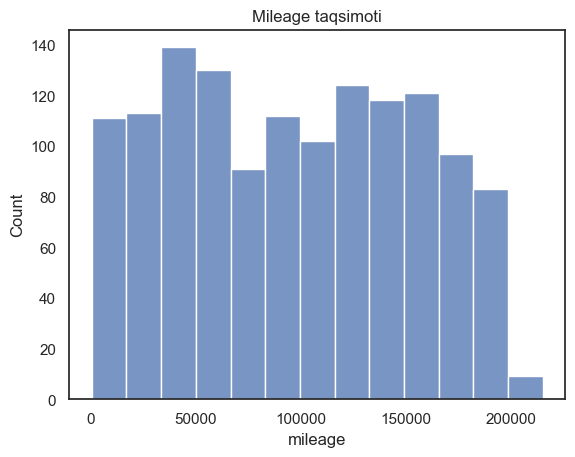

In [42]:
# TODO: mileage taqsimoti
sns.histplot(df_cleaned['mileage'])
plt.title('Mileage taqsimoti')
plt.show()

<Axes: xlabel='mileage', ylabel='Count'>

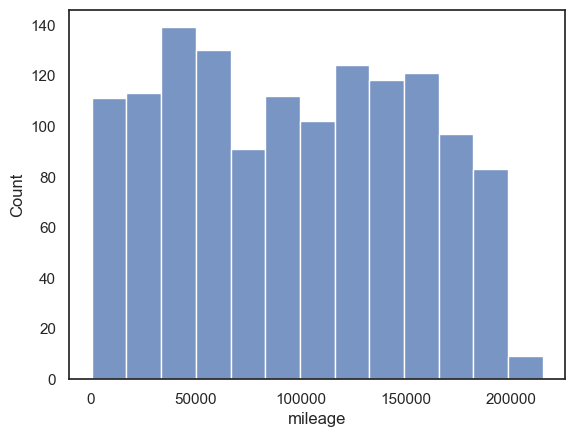

In [43]:
sns.histplot(df_cleaned['mileage'])

In [44]:
df_cleaned.head()

,car_age,mileage,engine_size,owners,is_automatic,has_accident,price,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,city_tier_tier2,city_tier_tier3
0,12,147184,2.2,0,0,yes,2779.46,False,False,True,False,False
1,5,57179,1.2,0,1,yes,15101.28,False,False,True,True,False
2,11,135666,1.9,2,0,yes,3428.63,False,False,False,True,False
3,5,63793,2.2,1,0,no,19633.44,False,False,False,False,False
4,6,83474,1.7,1,1,no,22904.57,False,True,False,False,False


In [45]:
df['mileage'].value_counts()

mileage
500       22
175975     3
107903     3
56512      2
152825     2
          ..
160370     1
56674      1
70966      1
139109     1
100090     1
Name: count, Length: 1318, dtype: int64

In [46]:
df_cleaned.columns

Index(['car_age', 'mileage', 'engine_size', 'owners', 'is_automatic',
       'has_accident', 'price', 'fuel_type_electric', 'fuel_type_hybrid',
       'fuel_type_petrol', 'city_tier_tier2', 'city_tier_tier3'],
      dtype='object')

In [47]:
# TODO: pd.cut orqali mileage_category yarating
df_cleaned['mileage_category']=pd.cut(
    df_cleaned['mileage'],
    bins=[0,40000,100000,160000,float('inf')],
    labels=['Low','Medium','High','Very high'])
df_cleaned[['mileage','mileage_category']].head()

,mileage,mileage_category
0,147184,High
1,57179,Medium
2,135666,High
3,63793,Medium
4,83474,Medium


In [48]:
df_cleaned.columns

Index(['car_age', 'mileage', 'engine_size', 'owners', 'is_automatic',
       'has_accident', 'price', 'fuel_type_electric', 'fuel_type_hybrid',
       'fuel_type_petrol', 'city_tier_tier2', 'city_tier_tier3',
       'mileage_category'],
      dtype='object')

In [49]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['mileage_category'], drop_first=True)
df_cleaned.head()

,car_age,mileage,engine_size,owners,is_automatic,has_accident,price,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,city_tier_tier2,city_tier_tier3,mileage_category_Medium,mileage_category_High,mileage_category_Very high
0,12,147184,2.2,0,0,yes,2779.46,False,False,True,False,False,False,True,False
1,5,57179,1.2,0,1,yes,15101.28,False,False,True,True,False,True,False,False
2,11,135666,1.9,2,0,yes,3428.63,False,False,False,True,False,False,True,False
3,5,63793,2.2,1,0,no,19633.44,False,False,False,False,False,True,False,False
4,6,83474,1.7,1,1,no,22904.57,False,True,False,False,False,True,False,False


In [50]:
df_cleaned.columns


Index(['car_age', 'mileage', 'engine_size', 'owners', 'is_automatic',
       'has_accident', 'price', 'fuel_type_electric', 'fuel_type_hybrid',
       'fuel_type_petrol', 'city_tier_tier2', 'city_tier_tier3',
       'mileage_category_Medium', 'mileage_category_High',
       'mileage_category_Very high'],
      dtype='object')

In [51]:
# TODO: car_age, mileage, engine_size, owners uchun StandardScaler
from sklearn.preprocessing import StandardScaler
cols=['car_age','mileage','engine_size','owners']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

## 6. Belgilarni Tanlash — Pirson Korrelyatsiyasi (Pearson Correlation)
Har bir sonli/binar belgi uchun `scipy.stats.pearsonr` yordamida `price` bilan Pirson korrelyatsiyasini hisoblang. Eng kuchlidan eng kuchsizgacha tartiblangan xulosa DataFrame yarating.

In [52]:
from scipy.stats import pearsonr
# TODO: selected_features ro'yxati, korrelyatsiya lug'ati, correlation_df
selected_features=[c for c in df_cleaned.columns if c not in ['price']]
selected_features=[c for c in selected_features  if df_cleaned[c].dtype!='object']



In [53]:
df_cleaned[cols].dtypes

car_age        float64
mileage        float64
engine_size    float64
owners         float64
dtype: object

In [54]:
correlations={feature:pearsonr(df_cleaned[feature].astype(float), df_cleaned['price'])[0]
             for feature in selected_features}
correlation_df=pd.DataFrame(list(correlations.items()), columns=['Feature','Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
10,mileage_category_Medium,0.320500
5,fuel_type_electric,0.160904
2,engine_size,0.090944
6,fuel_type_hybrid,0.064438
4,is_automatic,0.030830
8,city_tier_tier2,-0.000372
3,owners,-0.042023
9,city_tier_tier3,-0.082048
7,fuel_type_petrol,-0.082765
11,mileage_category_High,-0.387305


## 7. Belgilarni Tanlash — Xi-kvadrat Testi (Chi-Square Test)
1. `price`ni `pd.qcut(..., q=4, labels=False)` yordamida 4 ta kvantil guruhiga bo'ling.
2. Har bir kategorik/binar belgi uchun `scipy.stats.chi2_contingency` yordamida `price` guruhiga nisbatan xi-kvadrat mustaqillik testini o'tkazing.
3. Xi-kvadrat statistikasi, p-qiymati va alpha = 0.05 darajasida Saqlash/Tashlash qarorini ko'rsatuvchi natijalar jadvalini yarating.

## 8. Yakuniy Belgilar To'plami
Pirson korrelyatsiyasi va xi-kvadrat natijalaringizga asoslanib, `price` va siz tanlagan belgilarni o'z ichiga olgan `final_df` yarating. Qaysi belgilarni nima uchun tashlab yuborganingizni markdown katakchada qisqacha asoslang.

In [55]:
from scipy.stats import chi2_contingency
alpha = 0.05
# TODO: price_bin, chi2 sikli, natijalar jadvali
df_cleaned['price_bin']=pd.qcut(df_cleaned['price'], q=4, labels=False)


In [56]:
# TODO: final_df = df_cleaned[[...]]
chi2_results={}

In [57]:
for col in selected_features:
    contingency=pd.crosstab(df_cleaned[col], df_cleaned['price_bin'])
    chi2_stat, p_val,_,_=chi2_contingency(contingency)
    decision='Reject Null(Keep Feature)' if p_val<alpha else 'Accept Null(Drop Feature)'
    chi2_results[col]={'chi2_statistic':chi2_stat, 'p_value':p_val,'Decision':decision}

In [58]:
final_df=df_cleaned[[
    'car_age', 'mileage', 'engine_size', 'owners', 'is_automatic',
       'has_accident', 'price', 'fuel_type_electric', 'fuel_type_hybrid',
       'fuel_type_petrol', 'city_tier_tier2', 'city_tier_tier3',
       'mileage_category_Medium', 'mileage_category_High',
       'mileage_category_Very high', 'price_bin']]
final_df

,car_age,mileage,engine_size,owners,is_automatic,has_accident,price,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,city_tier_tier2,city_tier_tier3,mileage_category_Medium,mileage_category_High,mileage_category_Very high,price_bin
0,0.988289,0.890891,0.640605,-0.959039,0,yes,2779.46,False,False,True,False,False,False,True,False,0
1,-0.510801,-0.697491,-1.123967,-0.959039,1,yes,15101.28,False,False,True,True,False,True,False,False,1
2,0.774133,0.687624,0.111233,1.161686,0,yes,3428.63,False,False,False,True,False,False,True,False,0
3,-0.510801,-0.580769,0.640605,0.101324,0,no,19633.44,False,False,False,False,False,True,False,False,2
4,-0.296645,-0.233444,-0.241681,0.101324,1,no,22904.57,False,True,False,False,False,True,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,0.559978,0.580062,-0.241681,1.161686,0,no,11101.30,False,False,True,True,False,False,True,False,1
1360,-1.581580,-1.697745,0.287691,1.161686,1,no,29774.28,False,False,True,False,False,False,False,False,3
1361,0.345822,0.356536,1.346434,-0.959039,0,no,11321.43,False,False,False,True,False,False,True,False,1
1362,0.559978,0.590650,0.464148,-0.959039,1,yes,6631.13,False,False,True,False,True,False,True,False,0


In [59]:
# train va test 29.07.2026
X=final_df.drop('price', axis=1)
y=final_df['price']

In [60]:
'price' in df_cleaned.columns

True

In [61]:
'price' in final_df.columns

True

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [74]:
# X va y
X = final_df.drop('price', axis=1)
y = final_df['price']   # ❗ MUHIM

# encoding
X = pd.get_dummies(X, drop_first=True)

# NaN tozalash
X = X.fillna(0)
y = y.fillna(0)

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# model
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)

rf_model.fit(X_train, y_train)

print("✅ Model muvaffaqiyatli o‘qitildi")

✅ Model muvaffaqiyatli o‘qitildi


In [ ]:
"""from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=300,           max_depth=10,           random_state=42)
rf_model.fit(X_train, y_train)
print("model muvaffaqiyatli o'qitildi")

In [75]:
yangi_mashina = pd.DataFrame([{
    'car_age': 0.7,
    'mileage': 0,
    'engine_size': 2.0,
    'owners': 1,
    'is_automatic': 1,
    'has_accident': 0,
    

    'fuel_type_petrol': 1,
    
    'city_tier_tier2': 1,
    
    
    'mileage_category_High': 1
}])
yangi_mashina = yangi_mashina.reindex(columns=X.columns, fill_value=0)
yangi_mashina = yangi_mashina[X.columns]

narx = rf_model.predict(yangi_mashina)

print(f" Mashina narxi: ${narx[0]:.2f}")


 Mashina narxi: $5657.62


In [76]:
taxminiy_narx = rf_model.predict(yangi_mashina)

print(f" Taxmin qilingan mashina narxi: ${taxminiy_narx[0]:.2f}")

 Taxmin qilingan mashina narxi: $5657.62


In [77]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)
pred=rf_model.predict(X_test)
mae=mean_absolute_error(y_test, pred)
mse=mean_squared_error(y_test,pred)
roots=mae**0.5
r2=r2_score(y_test,pred)
print(" mean absolute error",mae)
print(" mean squared error",mse)
print(" root error",roots)
print(" R2", r2)

 mean absolute error 1193.3629919656757
 mean squared error 2276394.2199308584
 root error 34.54508636500531
 R2 0.9732046079905007


In [78]:
rf_model.fit(X_train,y_train)
pred=rf_model.predict(X_test)

In [79]:
natija=pd.DataFrame({
    "Actual": y_test,
    "Predicted":pred
})
natija["Error"]=natija["Actual"]-natija["Predicted"]
print(natija)

        Actual     Predicted        Error
291    2794.31   5022.021105 -2227.711105
1046  25651.06  24827.914949   823.145051
538   12910.35  12938.161718   -27.811718
348    1200.00   2158.660735  -958.660735
1086  21798.62  19995.924485  1802.695515
...        ...           ...          ...
532   14526.71  12894.974339  1631.735661
531    5380.12   5542.746765  -162.626765
583   24112.00  24903.240305  -791.240305
353   19932.11  19051.108709   881.001291
516    9204.73   9297.097086   -92.367086

[338 rows x 3 columns]


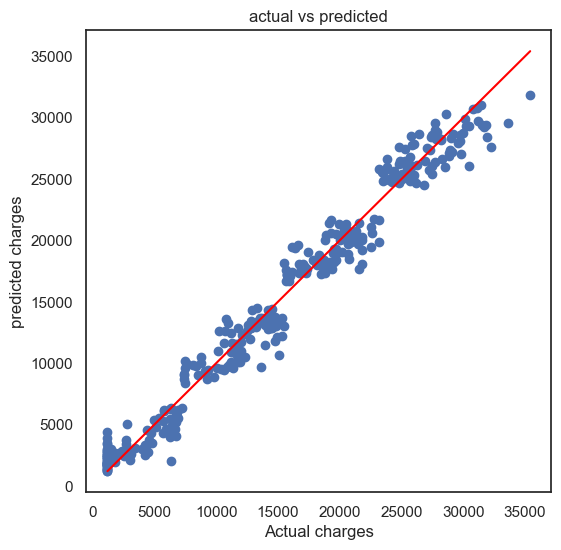

In [80]:
import matplotlib.pyplot as plt
plt.figure (figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual charges")
plt.ylabel("predicted charges")
plt.title("actual vs predicted")
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)
plt.show()